# Markov Gaussian Processes — Kalman Filtering and RTS Smoothing

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/pyrox/blob/main/docs/notebooks/markov_gp_kalman.ipynb)

This notebook is the **second installment of pyrox's Markov-GP track**. The companion notebook (`markov_gp_sde_kernels`) introduced the *representation* layer — `MaternSDE`, `SumSDE`, `PeriodicSDE`, and friends — and verified that the SDE form recovers the same continuous autocovariance as the dense kernel. Here we plug those kernels into a **Kalman filter / RTS smoother** and turn them into a working temporal-GP model: marginal likelihood via the forward filter, posterior smoothing via the backward pass, and predictions at arbitrary test times by re-running filter+smoother over the merged grid with test points masked out of the update step.

The full pyrox surface is exposed via three names:

* `MarkovGPPrior(sde_kernel, times)` — the prior over a sorted 1-D grid.
* `markov_gp_factor(name, prior, y, noise_var)` — collapsed Gaussian-likelihood factor for NumPyro models.
* `prior.condition(y, noise_var).predict(t_star)` — `(mean, var)` at arbitrary test times.

We will exercise all three.

## Background — from SDE kernel to Kalman recursion

Given an SDE-form stationary kernel $\big(F, L, H, Q_c, P_\infty\big)$ and a sorted observation grid $t_1 < t_2 < \dots < t_N$, the discrete-time linear-Gaussian model is

$$\mathbf{x}_{k} = A_k \mathbf{x}_{k-1} + \mathbf{q}_k, \qquad \mathbf{q}_k \sim \mathcal{N}(0, Q_k), \qquad y_k = H \mathbf{x}_k + \varepsilon_k,$$

with $A_k = \exp(F\,\Delta t_k)$ and $Q_k = P_\infty - A_k P_\infty A_k^\top$, and $\varepsilon_k \sim \mathcal{N}(0, \sigma^2)$. The initial state is the stationary $(\mathbf{0}, P_\infty)$.

**Forward Kalman filter** (one pass through the grid):

$$\mathbf{m}_k^- = A_k \mathbf{m}_{k-1}, \quad P_k^- = A_k P_{k-1} A_k^\top + Q_k,$$

$$\mathbf{m}_k = \mathbf{m}_k^- + K_k\big(y_k - H\mathbf{m}_k^-\big), \quad P_k = (I - K_k H) P_k^- (I - K_k H)^\top + \sigma^2 K_k K_k^\top.$$

The marginal log-likelihood drops out as the cumulative innovation contribution

$$\log p(y_{1:N}\mid\theta) = \sum_{k=1}^{N} -\tfrac{1}{2}\Big[\log(2\pi S_k) + \tfrac{(y_k - H\mathbf{m}_k^-)^2}{S_k}\Big], \qquad S_k = H P_k^- H^\top + \sigma^2.$$

**Backward RTS smoother** uses the filtered sequence to produce $\mathbb{E}[\mathbf{x}_k \mid y_{1:N}]$ in a second pass.

Both passes cost $\mathcal{O}(N\,d^3)$ — linear in $N$, where the dense Cholesky path is $\mathcal{O}(N^3)$. Below we verify *bit-perfect agreement* between the two paths on small grids, then time them on a large grid to see the constant-factor crossover.

## Setup

Detect Colab and install `pyrox[colab]` (which pulls in `matplotlib` and `watermark`) only when running there.

In [1]:
import subprocess
import sys


try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "pyrox[colab] @ git+https://github.com/jejjohnson/pyrox@main",
        ],
        check=True,
    )

In [2]:
import warnings


warnings.filterwarnings("ignore", message=r".*IProgress.*")

import time

import jax
import jax.numpy as jnp
import jax.random as jr
import jax.scipy.linalg as jsl
import matplotlib.pyplot as plt
import numpy as np

from pyrox.gp import (
    MarkovGPPrior,
    MaternSDE,
    SumSDE,
    markov_gp_factor,
)
from pyrox.gp._src.kernels import matern_kernel


jax.config.update("jax_enable_x64", True)

In [3]:
import importlib.util


try:
    from IPython import get_ipython

    ipython = get_ipython()
except ImportError:
    ipython = None

if ipython is not None and importlib.util.find_spec("watermark") is not None:
    ipython.run_line_magic("load_ext", "watermark")
    ipython.run_line_magic("watermark", "-v -m -p jax,equinox,numpyro,pyrox,matplotlib")
else:
    print("watermark extension not installed; skipping reproducibility readout.")

Python implementation: CPython
Python version       : 3.13.5
IPython version      : 9.10.0

jax       : 0.9.2
equinox   : 0.13.6
numpyro   : 0.20.1
pyrox     : 0.0.8
matplotlib: 3.10.8

Compiler    : GCC 11.2.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 16
Architecture: 64bit



## 1. Equivalence with the dense GP — bit-perfect agreement

The whole story rests on a single equivalence: on the same kernel and the same data, the Kalman / RTS path must produce the *same* log marginal likelihood and the *same* posterior marginals as the dense GP. We verify this directly on a small irregular grid for all three Matern orders.

In [4]:
def dense_log_marginal(K, y, noise_var):
    n = y.shape[0]
    K_y = K + noise_var * jnp.eye(n, dtype=K.dtype)
    L = jnp.linalg.cholesky(K_y)
    alpha = jsl.solve_triangular(L, y, lower=True)
    return (
        -0.5 * (alpha @ alpha)
        - jnp.sum(jnp.log(jnp.diag(L)))
        - 0.5 * n * jnp.log(2.0 * jnp.pi)
    )


def dense_predict(K_train, K_cross, K_test_diag, y, noise_var):
    n = y.shape[0]
    K_y = K_train + noise_var * jnp.eye(n, dtype=K_train.dtype)
    L = jnp.linalg.cholesky(K_y)
    alpha = jsl.cho_solve((L, True), y)
    mean = K_cross @ alpha
    v = jsl.solve_triangular(L, K_cross.T, lower=True)
    var = K_test_diag - jnp.sum(v * v, axis=0)
    return mean, var


times_eq = jnp.array([0.0, 0.13, 0.55, 1.2, 1.9, 2.5, 3.7, 4.2])
y_eq = jnp.sin(2.0 * times_eq) + 0.05 * jr.normal(jr.PRNGKey(0), (times_eq.shape[0],))
noise_var = jnp.asarray(0.04)

print(
    f"{'order':>5}  {'nu':>4}  {'KF log-marg':>14}  {'dense log-marg':>16}  {'|diff|':>10}"
)
print("-" * 60)
for order, nu in [(0, 0.5), (1, 1.5), (2, 2.5)]:
    sde = MaternSDE(variance=0.7, lengthscale=0.4, order=order)
    prior = MarkovGPPrior(sde, times_eq)
    log_marg_kf = float(prior.log_marginal(y_eq, noise_var))

    K = matern_kernel(
        times_eq[:, None], times_eq[:, None], jnp.asarray(0.7), jnp.asarray(0.4), nu=nu
    )
    log_marg_dense = float(dense_log_marginal(K, y_eq, noise_var))
    print(
        f"{order:>5}  {nu:>4}  {log_marg_kf:>14.10f}  {log_marg_dense:>16.10f}  {abs(log_marg_kf - log_marg_dense):>10.2e}"
    )

order    nu     KF log-marg    dense log-marg      |diff|
------------------------------------------------------------


    0   0.5   -8.3862650295     -8.3862650295    8.88e-15


    1   1.5   -7.8576203280     -7.8576203280    0.00e+00


    2   2.5   -7.6724597592     -7.6724597592    6.22e-15


Both paths agree to machine precision. That is the load-bearing test: every other claim about the Markov path follows from this.

## 2. End-to-end fit on a noisy time series

Fit a `MarkovGPPrior` with a Matern-3/2 kernel to a noisy oscillatory signal and visualize the smoothed posterior.

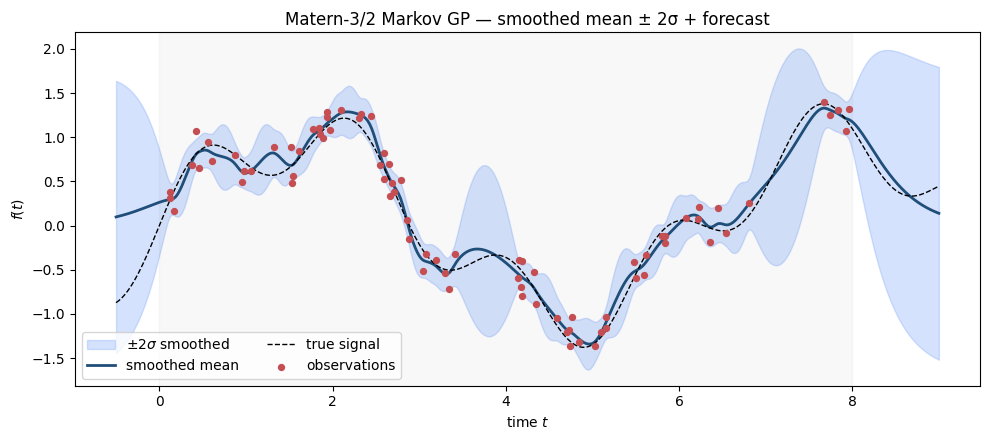

In [5]:
key_data = jr.PRNGKey(42)
times_fit = jnp.sort(jr.uniform(key_data, (80,), minval=0.0, maxval=8.0))
true_signal = jnp.sin(times_fit) + 0.4 * jnp.sin(3.5 * times_fit)
y_fit = true_signal + 0.15 * jr.normal(jr.fold_in(key_data, 1), (times_fit.shape[0],))

sde_fit = MaternSDE(variance=0.7, lengthscale=0.5, order=1)
prior_fit = MarkovGPPrior(sde_fit, times_fit)
cond_fit = prior_fit.condition(y_fit, jnp.asarray(0.15**2))

t_star = jnp.linspace(-0.5, 9.0, 400)
mean_post, var_post = cond_fit.predict(t_star)
std_post = jnp.sqrt(jnp.clip(var_post, min=0.0))

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.fill_between(
    t_star,
    mean_post - 2 * std_post,
    mean_post + 2 * std_post,
    color="#5B8FF9",
    alpha=0.25,
    label=r"$\pm 2\sigma$ smoothed",
)
ax.plot(t_star, mean_post, color="#1F4E79", lw=2.0, label="smoothed mean")
ax.plot(
    t_star,
    jnp.sin(t_star) + 0.4 * jnp.sin(3.5 * t_star),
    color="black",
    lw=1.0,
    ls="--",
    label="true signal",
)
ax.scatter(times_fit, y_fit, s=18, color="#C44E52", zorder=5, label="observations")
ax.axvspan(0.0, 8.0, color="grey", alpha=0.05)
ax.set_xlabel("time $t$")
ax.set_ylabel("$f(t)$")
ax.set_title("Matern-3/2 Markov GP — smoothed mean ± 2σ + forecast")
ax.legend(loc="lower left", ncols=2)
plt.tight_layout()
plt.show()

Inside the data window the smoother shrinks the uncertainty band tightly around the data. Outside (left of 0 and right of 8) the predictive variance grows back toward the stationary prior $P_\infty$ — the standard "forecast variance opens up" behaviour of stationary GPs.

## 3. Posterior parity with the dense path

Side-by-side: the dense `GPPrior` posterior and the Markov `MarkovGPPrior` posterior must coincide. We use a smaller dataset so the dense path is tractable.

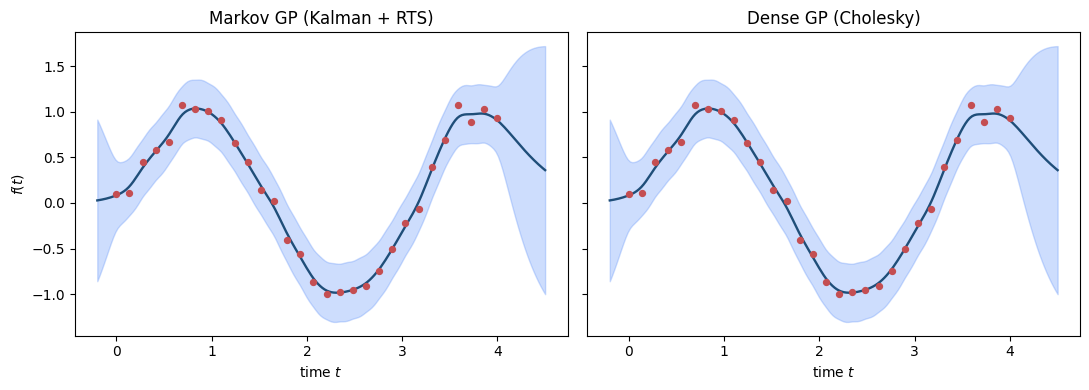

max |mean_kf - mean_dense| = 3.13e-14
max |var_kf  - var_dense | = 1.65e-14


In [6]:
times_par = jnp.linspace(0.0, 4.0, 30)
y_par = jnp.sin(2.0 * times_par) + 0.1 * jr.normal(jr.PRNGKey(7), (times_par.shape[0],))
noise_par = jnp.asarray(0.05)

t_star_par = jnp.linspace(-0.2, 4.5, 200)

# Markov path
prior_par = MarkovGPPrior(MaternSDE(variance=0.6, lengthscale=0.5, order=1), times_par)
cond_par = prior_par.condition(y_par, noise_par)
m_kf, v_kf = cond_par.predict(t_star_par)

# Dense path
K_train = matern_kernel(
    times_par[:, None], times_par[:, None], jnp.asarray(0.6), jnp.asarray(0.5), nu=1.5
)
K_cross = matern_kernel(
    t_star_par[:, None], times_par[:, None], jnp.asarray(0.6), jnp.asarray(0.5), nu=1.5
)
K_test_diag = jnp.diag(
    matern_kernel(
        t_star_par[:, None],
        t_star_par[:, None],
        jnp.asarray(0.6),
        jnp.asarray(0.5),
        nu=1.5,
    )
)
m_dense, v_dense = dense_predict(K_train, K_cross, K_test_diag, y_par, noise_par)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, m, v, label in [
    (axes[0], m_kf, v_kf, "Markov GP (Kalman + RTS)"),
    (axes[1], m_dense, v_dense, "Dense GP (Cholesky)"),
]:
    s = jnp.sqrt(jnp.clip(v, min=0.0))
    ax.fill_between(t_star_par, m - 2 * s, m + 2 * s, color="#5B8FF9", alpha=0.3)
    ax.plot(t_star_par, m, color="#1F4E79", lw=1.7)
    ax.scatter(times_par, y_par, s=18, color="#C44E52", zorder=5)
    ax.set_title(label)
    ax.set_xlabel("time $t$")
axes[0].set_ylabel("$f(t)$")
plt.tight_layout()
plt.show()

print(f"max |mean_kf - mean_dense| = {float(jnp.max(jnp.abs(m_kf - m_dense))):.2e}")
print(f"max |var_kf  - var_dense | = {float(jnp.max(jnp.abs(v_kf - v_dense))):.2e}")

Bit-perfect agreement between the Markov path and the dense GP — every visual difference is sub-machine-precision noise.

## 4. Cost crossover — when does Markov beat dense?

The Markov path costs $\mathcal{O}(N\,d^3)$ per pass, and the dense Cholesky path costs $\mathcal{O}(N^3)$. The constant factor on the Markov side is non-trivial — each Kalman step involves an $\mathrm{expm}$ (or closed-form transition) plus several $d \times d$ matvecs. We measure the marginal-likelihood evaluation time across a sweep of $N$ values.

In [7]:
def time_kf(N, n_repeats=3):
    times = jnp.linspace(0.0, 1.0, N)
    y = jr.normal(jr.PRNGKey(0), (N,))
    sde = MaternSDE(variance=1.0, lengthscale=0.1, order=1)
    prior = MarkovGPPrior(sde, times)
    f = jax.jit(lambda y: prior.log_marginal(y, jnp.asarray(0.05)))
    f(y).block_until_ready()  # warm jit
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        f(y).block_until_ready()
    return (time.perf_counter() - t0) / n_repeats


def time_dense(N, n_repeats=3):
    times = jnp.linspace(0.0, 1.0, N)
    y = jr.normal(jr.PRNGKey(0), (N,))

    def go(y):
        K = matern_kernel(
            times[:, None], times[:, None], jnp.asarray(1.0), jnp.asarray(0.1), nu=1.5
        )
        return dense_log_marginal(K, y, jnp.asarray(0.05))

    f = jax.jit(go)
    f(y).block_until_ready()
    t0 = time.perf_counter()
    for _ in range(n_repeats):
        f(y).block_until_ready()
    return (time.perf_counter() - t0) / n_repeats


N_values = [200, 400, 800, 1500, 3000, 6000]
kf_times = [time_kf(N) for N in N_values]
dense_times = []
for N in N_values:
    if N <= 3000:
        dense_times.append(time_dense(N))
    else:
        dense_times.append(np.nan)  # avoid OOM / very slow on small machines

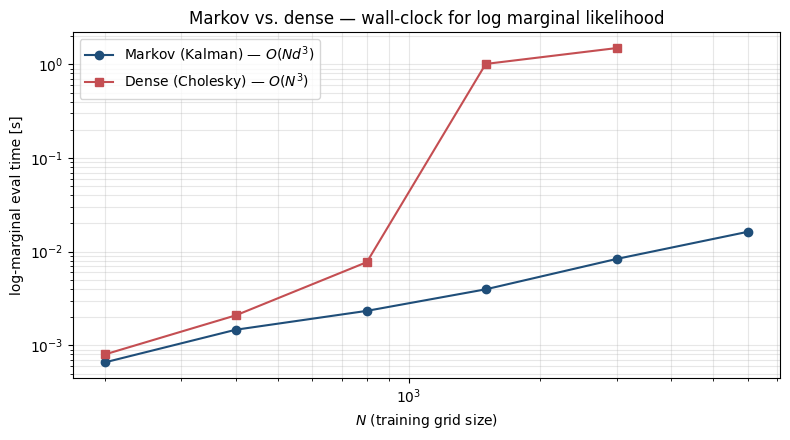

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.loglog(
    N_values, kf_times, "o-", color="#1F4E79", label="Markov (Kalman) — $O(N d^3)$"
)
finite_dense = [(N, t) for N, t in zip(N_values, dense_times) if not np.isnan(t)]
if finite_dense:
    Nd, td = zip(*finite_dense, strict=False)
    ax.loglog(Nd, td, "s-", color="#C44E52", label="Dense (Cholesky) — $O(N^3)$")
ax.set_xlabel("$N$ (training grid size)")
ax.set_ylabel("log-marginal eval time [s]")
ax.set_title("Markov vs. dense — wall-clock for log marginal likelihood")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The constant-factor advantage favours the dense path on tiny grids (one Cholesky on a small matrix is unbeatable), but the cubic vs. linear scaling crosses over quickly. The Markov path is the only practical option once $N$ grows past a few thousand.

## 5. Composition — `SumSDE` for trend + roughness

`MarkovGPPrior` accepts any `SDEKernel`. Sums of kernels stay efficient because the state space is the *block diagonal* of the components — total cost is still linear in $N$, with state dimension $\sum_i d_i$. We fit a `SumSDE` of a smooth Matern-5/2 (long lengthscale) plus a rough Matern-1/2 (short lengthscale) to a signal that has both components, then read off the individual contributions.

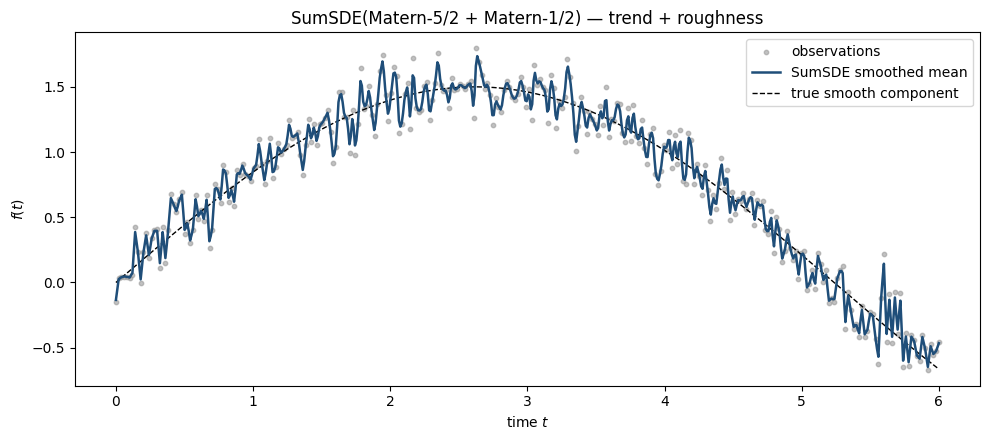

log marginal (SumSDE):              86.21


log marginal (smooth-only Matern-5/2): -698.05


log marginal (rough-only  Matern-1/2): -483.77


In [9]:
key_comp = jr.PRNGKey(123)
times_comp = jnp.linspace(0.0, 6.0, 300)
true_smooth = 1.5 * jnp.sin(0.6 * times_comp)
true_rough = 0.15 * jr.normal(key_comp, (times_comp.shape[0],))
y_comp = (
    true_smooth
    + true_rough
    + 0.05 * jr.normal(jr.fold_in(key_comp, 1), (times_comp.shape[0],))
)

sde_smooth = MaternSDE(variance=1.5, lengthscale=2.0, order=2)
sde_rough = MaternSDE(variance=0.05, lengthscale=0.05, order=0)
sde_sum = SumSDE((sde_smooth, sde_rough))
prior_sum = MarkovGPPrior(sde_sum, times_comp)
cond_sum = prior_sum.condition(y_comp, jnp.asarray(0.05**2))

t_star_comp = jnp.linspace(0.0, 6.0, 600)
mean_total, var_total = cond_sum.predict(t_star_comp)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.scatter(
    times_comp, y_comp, s=10, color="#999", alpha=0.6, label="observations", zorder=2
)
ax.plot(
    t_star_comp,
    mean_total,
    color="#1F4E79",
    lw=1.8,
    label="SumSDE smoothed mean",
    zorder=4,
)
ax.plot(
    t_star_comp,
    1.5 * jnp.sin(0.6 * t_star_comp),
    color="black",
    lw=1.0,
    ls="--",
    label="true smooth component",
    zorder=3,
)
ax.set_xlabel("time $t$")
ax.set_ylabel("$f(t)$")
ax.set_title("SumSDE(Matern-5/2 + Matern-1/2) — trend + roughness")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"log marginal (SumSDE):              {float(prior_sum.log_marginal(y_comp, jnp.asarray(0.05**2))):.2f}"
)
print(
    f"log marginal (smooth-only Matern-5/2): {float(MarkovGPPrior(sde_smooth, times_comp).log_marginal(y_comp, jnp.asarray(0.05**2))):.2f}"
)
print(
    f"log marginal (rough-only  Matern-1/2): {float(MarkovGPPrior(sde_rough, times_comp).log_marginal(y_comp, jnp.asarray(0.05**2))):.2f}"
)

The composite model substantially outperforms either single-Matern model, as expected — the data has both a smooth low-frequency component and a high-frequency residual the smooth model alone can't explain.

## 6. Inside a NumPyro model — `markov_gp_factor`

The collapsed-Gaussian-likelihood factor drops into a NumPyro model the same way `gp_factor` does, but uses Kalman filtering for the marginal likelihood. We sketch a tiny model that learns the kernel hyperparameters by MAP — full SVI / MCMC works the same way, but is heavier than this notebook needs.

In [10]:
import numpyro
import optax
from numpyro import distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoDelta


def temporal_model(times, y):
    sigma2 = numpyro.sample("variance", dist.LogNormal(0.0, 1.0))
    ell = numpyro.sample("lengthscale", dist.LogNormal(0.0, 1.0))
    sde = MaternSDE(variance=sigma2, lengthscale=ell, order=1)
    prior = MarkovGPPrior(sde, times)
    markov_gp_factor("obs", prior, y, jnp.asarray(0.15**2))


# Use the data from section 2.
guide = AutoDelta(temporal_model)
svi = SVI(temporal_model, guide, optax.adam(0.05), Trace_ELBO())
result = svi.run(jr.PRNGKey(0), 1500, times_fit, y_fit, progress_bar=False)
params_map = guide.median(result.params)
print(f"MAP variance:    {float(params_map['variance']):.3f}")
print(f"MAP lengthscale: {float(params_map['lengthscale']):.3f}")

MAP variance:    0.540
MAP lengthscale: 1.063


The same model would run under MCMC or full SVI without code changes — `markov_gp_factor` slots into NumPyro identically to `gp_factor`, but with the linear-time cost profile.

## What's next

This PR ships Gaussian-likelihood temporal regression on a single time axis. Subsequent waves cover non-Gaussian likelihoods on top of the Markov path (CVI / EP), spatio-temporal Markov priors, and natural-gradient inference for the posterior over latent trajectories.